# FineSightBench — Dataset Generation Validation

This notebook **generates, tests, and visually validates** both benchmark datasets:

| Dataset | Purpose | Task Types |
|---------|---------|------------|
| **FineSight-Perception** | Can the VLM *see* fine-grained targets? | letter, animal, block, color_block, shape |
| **FineSight-Reasoning** | Can the VLM *reason* about what it sees? | comparison, counting, spatial, CVD, blur, chain |

For every sample we verify: **Image** + **Prompt (question)** + **Label (JSON answer)**

In [3]:
%matplotlib inline
import json, textwrap
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from PIL import Image, ImageDraw

from finesightbench.perception import generate_perception_dataset
from finesightbench.reasoning import generate_reasoning_dataset


In [5]:
P_DIR = "data/val_data/perception"
R_DIR = "data/val_data/reasoning"

p_labels = generate_perception_dataset(P_DIR, canvas_size=448, num_per_config=10, seed=42)
r_labels = generate_reasoning_dataset(R_DIR, canvas_size=448, num_per_config=10, seed=42)

with open(p_labels) as f:
    p_data = json.load(f)
with open(r_labels) as f:
    r_data = json.load(f)

print(f"Perception : {p_data['dataset_info']['num_samples']} samples, "
      f"tasks = {p_data['dataset_info']['task_types']}")
print(f"Reasoning  : {r_data['dataset_info']['num_samples']} samples, "
      f"tasks = {r_data['dataset_info']['task_types']}")

[Perception] Generated 400 samples → data/val_data/perception
[Reasoning] Generated 480 samples → data/val_data/reasoning
Perception : 400 samples, tasks = ['letter', 'animal', 'block', 'color_block', 'shape']
Reasoning  : 480 samples, tasks = ['comparison', 'counting', 'spatial', 'interference_cvd', 'interference_blur', 'chain_reasoning']


---
## 2. JSON Label Structure

Each sample in `labels.json` contains the full information needed for VLM evaluation or training:
- `image_path` — relative path to the PNG
- `question` — the prompt sent to the VLM
- `answer` — ground-truth answer string
- `difficulty` — `extreme` / `hard` / `medium` / `easy`
- `metadata.targets` — list of target objects with type, value, size, position, color

In [3]:
# Show a full sample JSON for each dataset
for name, data in [("PERCEPTION", p_data), ("REASONING", r_data)]:
    print(f"{'─'*60}")
    print(f"  {name} — Example Sample (JSON)")
    print(f"{'─'*60}")
    print(json.dumps(data["samples"][0], indent=2, ensure_ascii=False))
    print()

────────────────────────────────────────────────────────────
  PERCEPTION — Example Sample (JSON)
────────────────────────────────────────────────────────────
{
  "image_id": "perception_letter_3px_00000",
  "image_path": "images/perception_letter_3px_00000.png",
  "dataset": "perception",
  "task_type": "letter_recognition",
  "question": "What letter is displayed in the image?",
  "answer": "U",
  "difficulty": "extreme",
  "metadata": {
    "canvas_size": [
      512,
      512
    ],
    "background_color": "white",
    "background_color_rgb": [
      255,
      255,
      255
    ],
    "targets": [
      {
        "type": "letter",
        "value": "U",
        "size": 3,
        "position": [
          22,
          389
        ],
        "color": "green",
        "color_rgb": [
          0,
          180,
          0
        ]
      }
    ]
  }
}

────────────────────────────────────────────────────────────
  REASONING — Example Sample (JSON)
───────────────────────────────────

---
## 3. Visualization Helper

The `show_card()` function renders each sample as a visual "card" showing:
- **Left**: the image with red bounding-box around each target
- **Right**: the prompt (question), ground-truth answer, and the full JSON label

In [4]:
def show_card(data_dir: str, sample: dict, figsize=(14, 4.2)):
    """Render a single sample as a visual card: image | prompt | label."""
    fig = plt.figure(figsize=figsize, facecolor=BG)
    gs = GridSpec(1, 2, width_ratios=[1, 1.4], wspace=0.05, figure=fig)

    # ── Left: image with bounding boxes ──
    ax_img = fig.add_subplot(gs[0])
    img = Image.open(Path(data_dir) / sample["image_path"]).copy()
    draw = ImageDraw.Draw(img)
    targets = sample["metadata"]["targets"]
    for t in targets:
        x, y = t["position"]
        sz = t["size"]
        pad = max(3, sz // 2)
        draw.rectangle([x - pad, y - pad, x + sz + pad, y + sz + pad],
                       outline=WARN, width=2)
    ax_img.imshow(img)
    ax_img.set_title(f"{sample['task_type']}  |  {sample['difficulty']}  |  {targets[0]['size']}px",
                     fontsize=10, color=ACCENT)
    ax_img.axis("off")

    # ── Right: prompt + answer + JSON label ──
    ax_txt = fig.add_subplot(gs[1])
    ax_txt.axis("off")

    prompt_text = sample["question"]
    answer_text = sample["answer"]
    label_json = json.dumps({
        "image_id": sample["image_id"],
        "task_type": sample["task_type"],
        "question": sample["question"],
        "answer": sample["answer"],
        "difficulty": sample["difficulty"],
        "targets": targets,
    }, indent=2, ensure_ascii=False)

    # Wrap long lines
    wrapped_json = "\n".join(
        textwrap.fill(line, width=72, subsequent_indent="  ")
        if len(line) > 72 else line
        for line in label_json.split("\n")
    )

    display_text = (
        f"PROMPT\n"
        f"{prompt_text}\n\n"
        f"ANSWER\n"
        f"{answer_text}\n\n"
        f"JSON LABEL\n"
        f"{wrapped_json}"
    )

    ax_txt.text(0.02, 0.97, display_text,
                transform=ax_txt.transAxes,
                fontsize=7.5, fontfamily="monospace",
                verticalalignment="top",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                          edgecolor="#e2e8f0", linewidth=0.8))
    plt.tight_layout()
    plt.show()


def show_cards_grid(data_dir: str, samples: list[dict], title: str = "",
                    cols: int = 2, img_size: float = 2.8):
    """Render multiple samples in a compact grid: each row = image + prompt + answer."""
    n = len(samples)
    rows = (n + cols - 1) // cols
    fig = plt.figure(figsize=(cols * 7.5, rows * img_size * 1.1), facecolor=BG)
    gs = GridSpec(rows, cols * 2, wspace=0.08, hspace=0.45, figure=fig)

    for idx, s in enumerate(samples):
        r, c = divmod(idx, cols)
        # image
        ax_img = fig.add_subplot(gs[r, c * 2])
        img = Image.open(Path(data_dir) / s["image_path"]).copy()
        draw = ImageDraw.Draw(img)
        for t in s["metadata"]["targets"]:
            x, y = t["position"]
            sz = t["size"]
            pad = max(3, sz // 2)
            draw.rectangle([x - pad, y - pad, x + sz + pad, y + sz + pad],
                           outline=WARN, width=2)
        ax_img.imshow(img)
        ax_img.axis("off")

        # text
        ax_txt = fig.add_subplot(gs[r, c * 2 + 1])
        ax_txt.axis("off")
        t0 = s["metadata"]["targets"][0]
        info = (
            f"Task: {s['task_type']}\n"
            f"Size: {t0['size']}px | Diff: {s['difficulty']}\n"
            f"{'─'*36}\n"
            f"Q: {s['question']}\n"
            f"{'─'*36}\n"
            f"A: {s['answer']}\n"
            f"{'─'*36}\n"
            f"Color: {t0['color']} | Pos: {t0['position']}"
        )
        if t0.get("value") and t0["type"] in ("letter", "animal", "shape"):
            info += f"\nValue: {t0['value']}"
        ax_txt.text(0.0, 0.95, info,
                    transform=ax_txt.transAxes,
                    fontsize=7, fontfamily="monospace",
                    verticalalignment="top",
                    bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                              edgecolor="#cbd5e1", linewidth=0.7))

    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", color=ACCENT, y=1.01)
    plt.show()

print("Visualization helpers defined ✓")

Visualization helpers defined ✓


---
## 4. Perception Dataset — Per-Task Sample Cards

One sample card per task type, showing the image (with red bounding box), the VLM prompt, and the expected answer.

/tmp/ipykernel_327068/2378315804.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


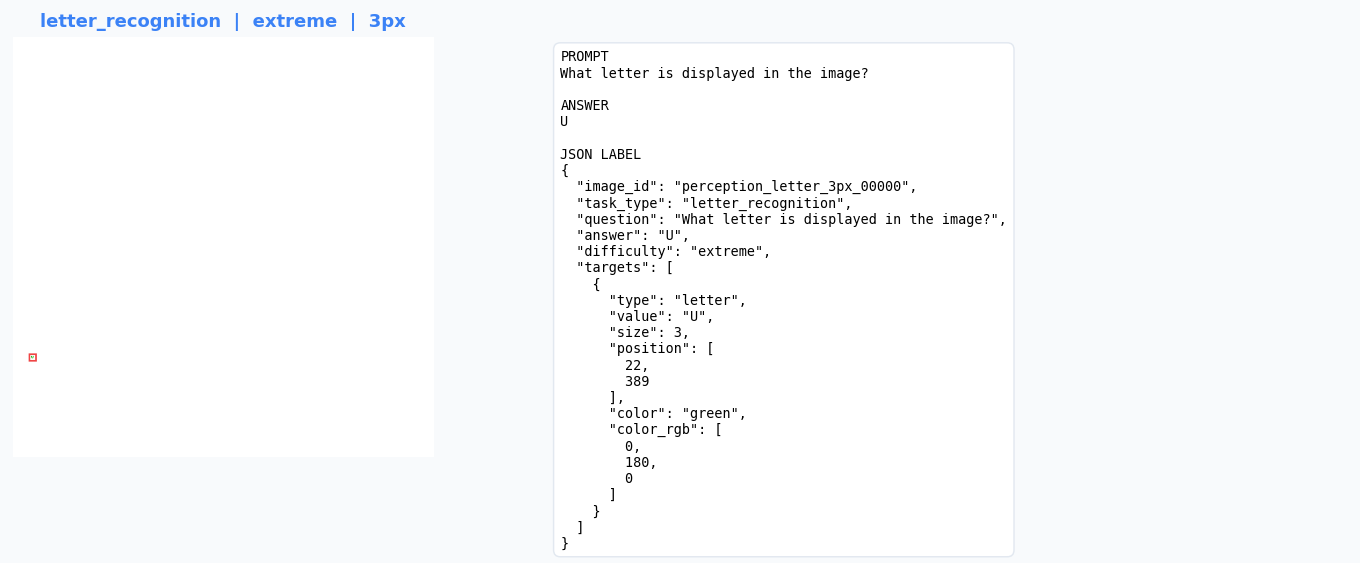

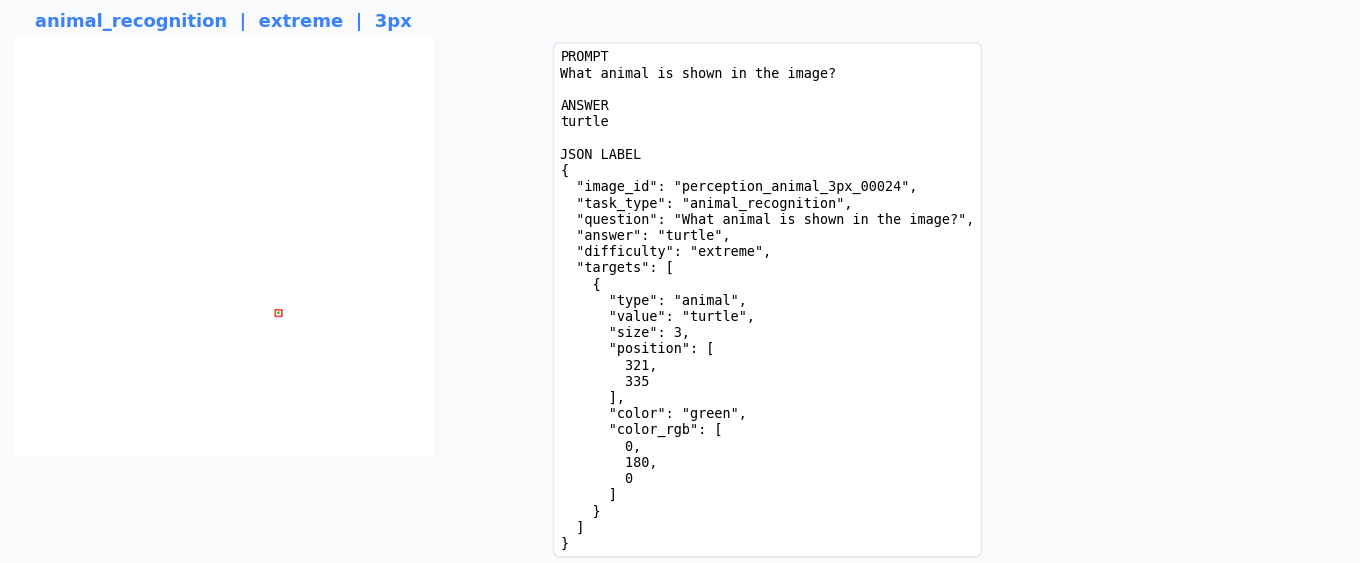

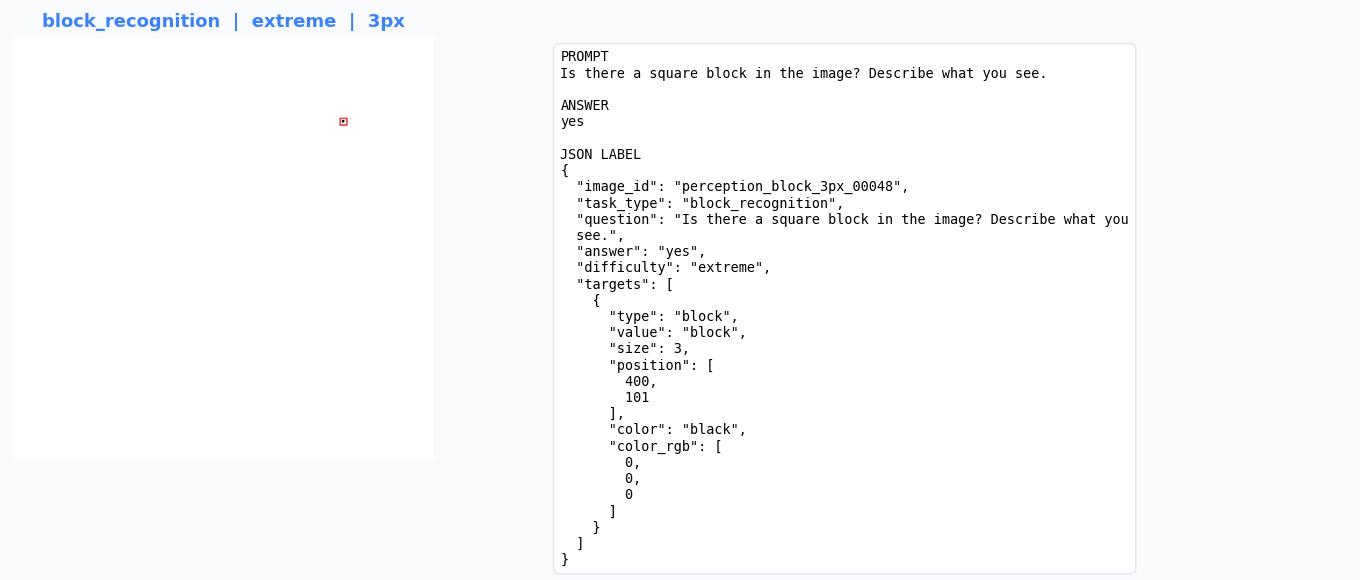

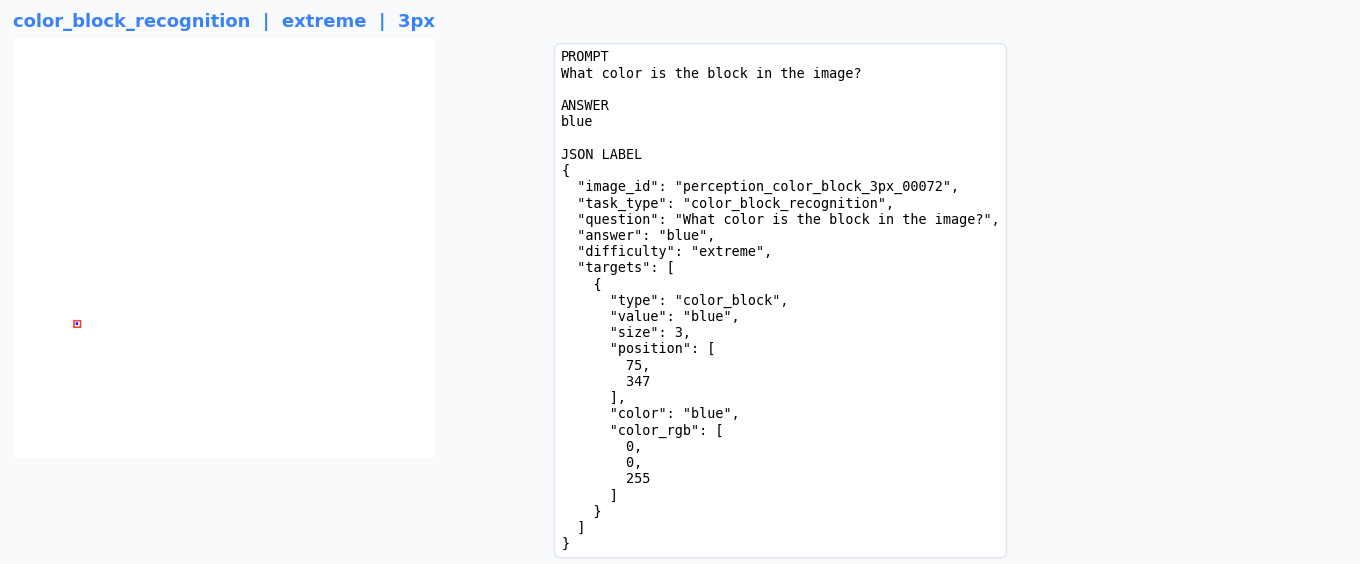

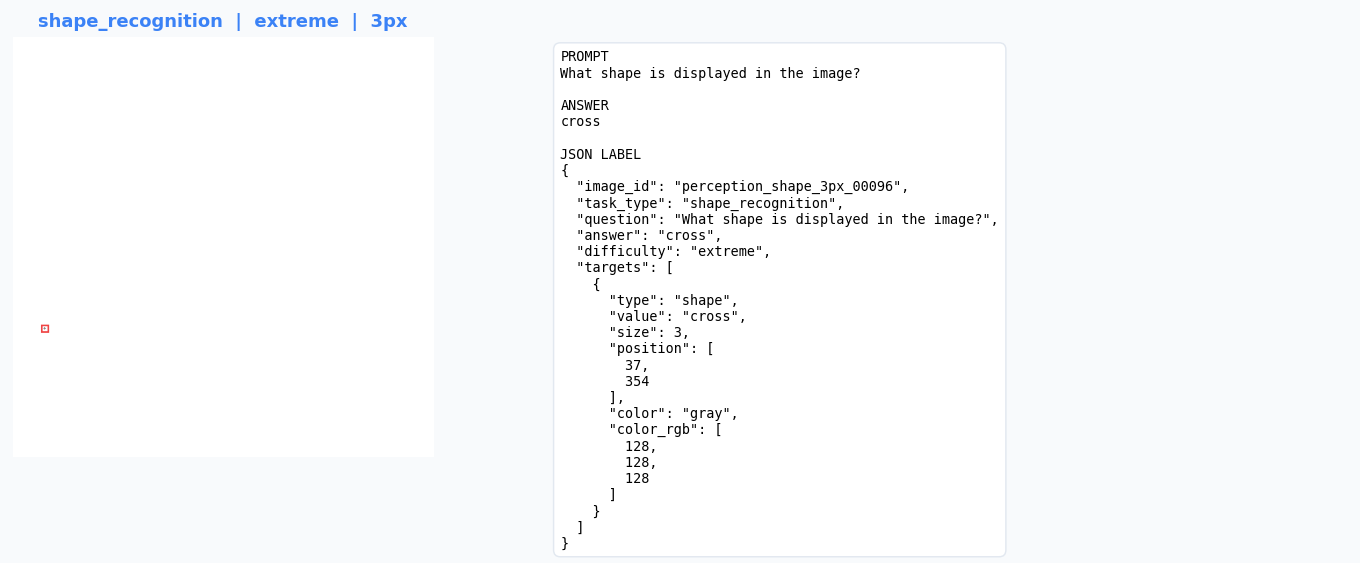

In [5]:
# Show one detailed card per perception task type
shown_tasks = set()
for s in p_data["samples"]:
    if s["task_type"] not in shown_tasks:
        shown_tasks.add(s["task_type"])
        show_card(P_DIR, s)

---
## 5. Reasoning Dataset — Per-Task Sample Cards

One sample card per reasoning task type.

/tmp/ipykernel_327068/2378315804.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


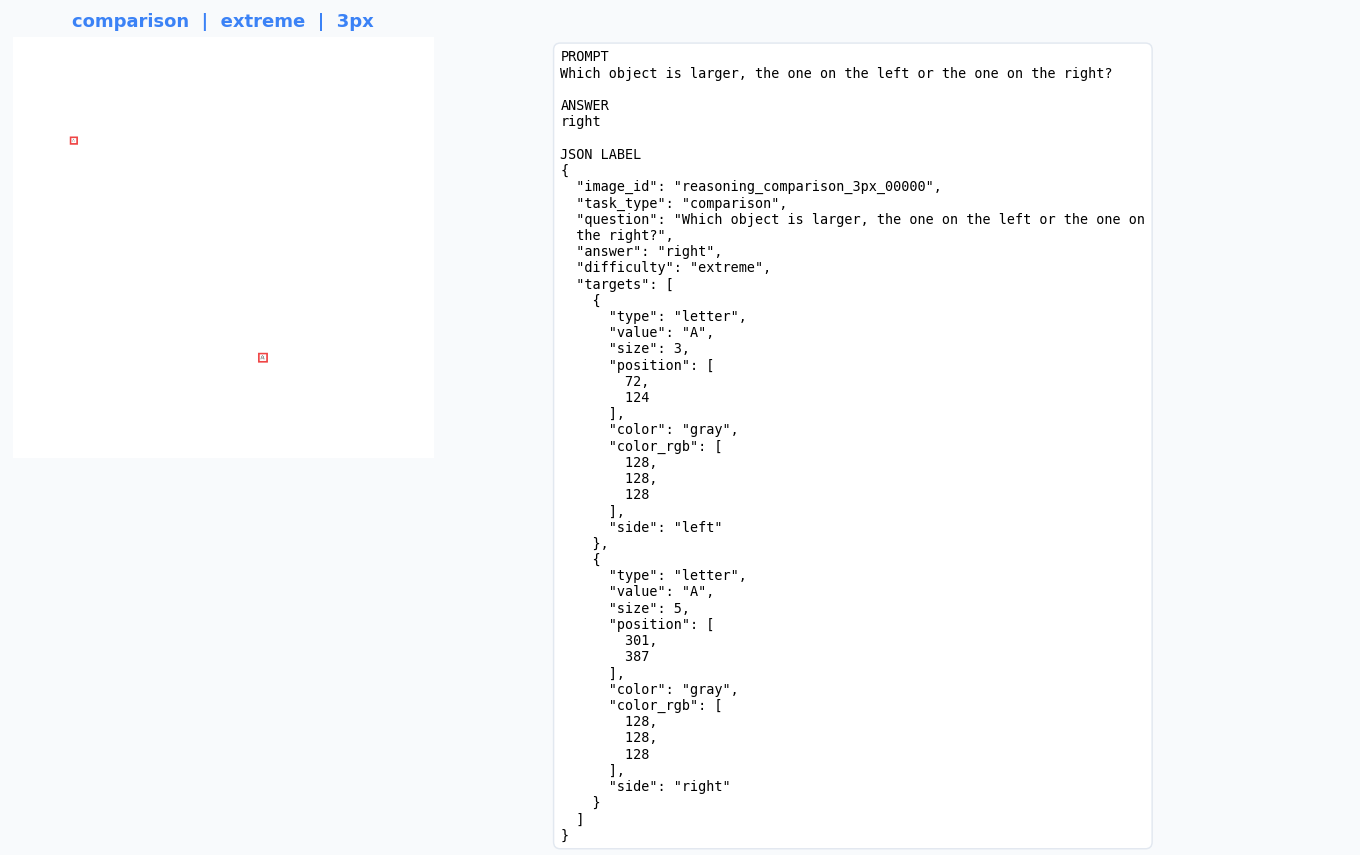

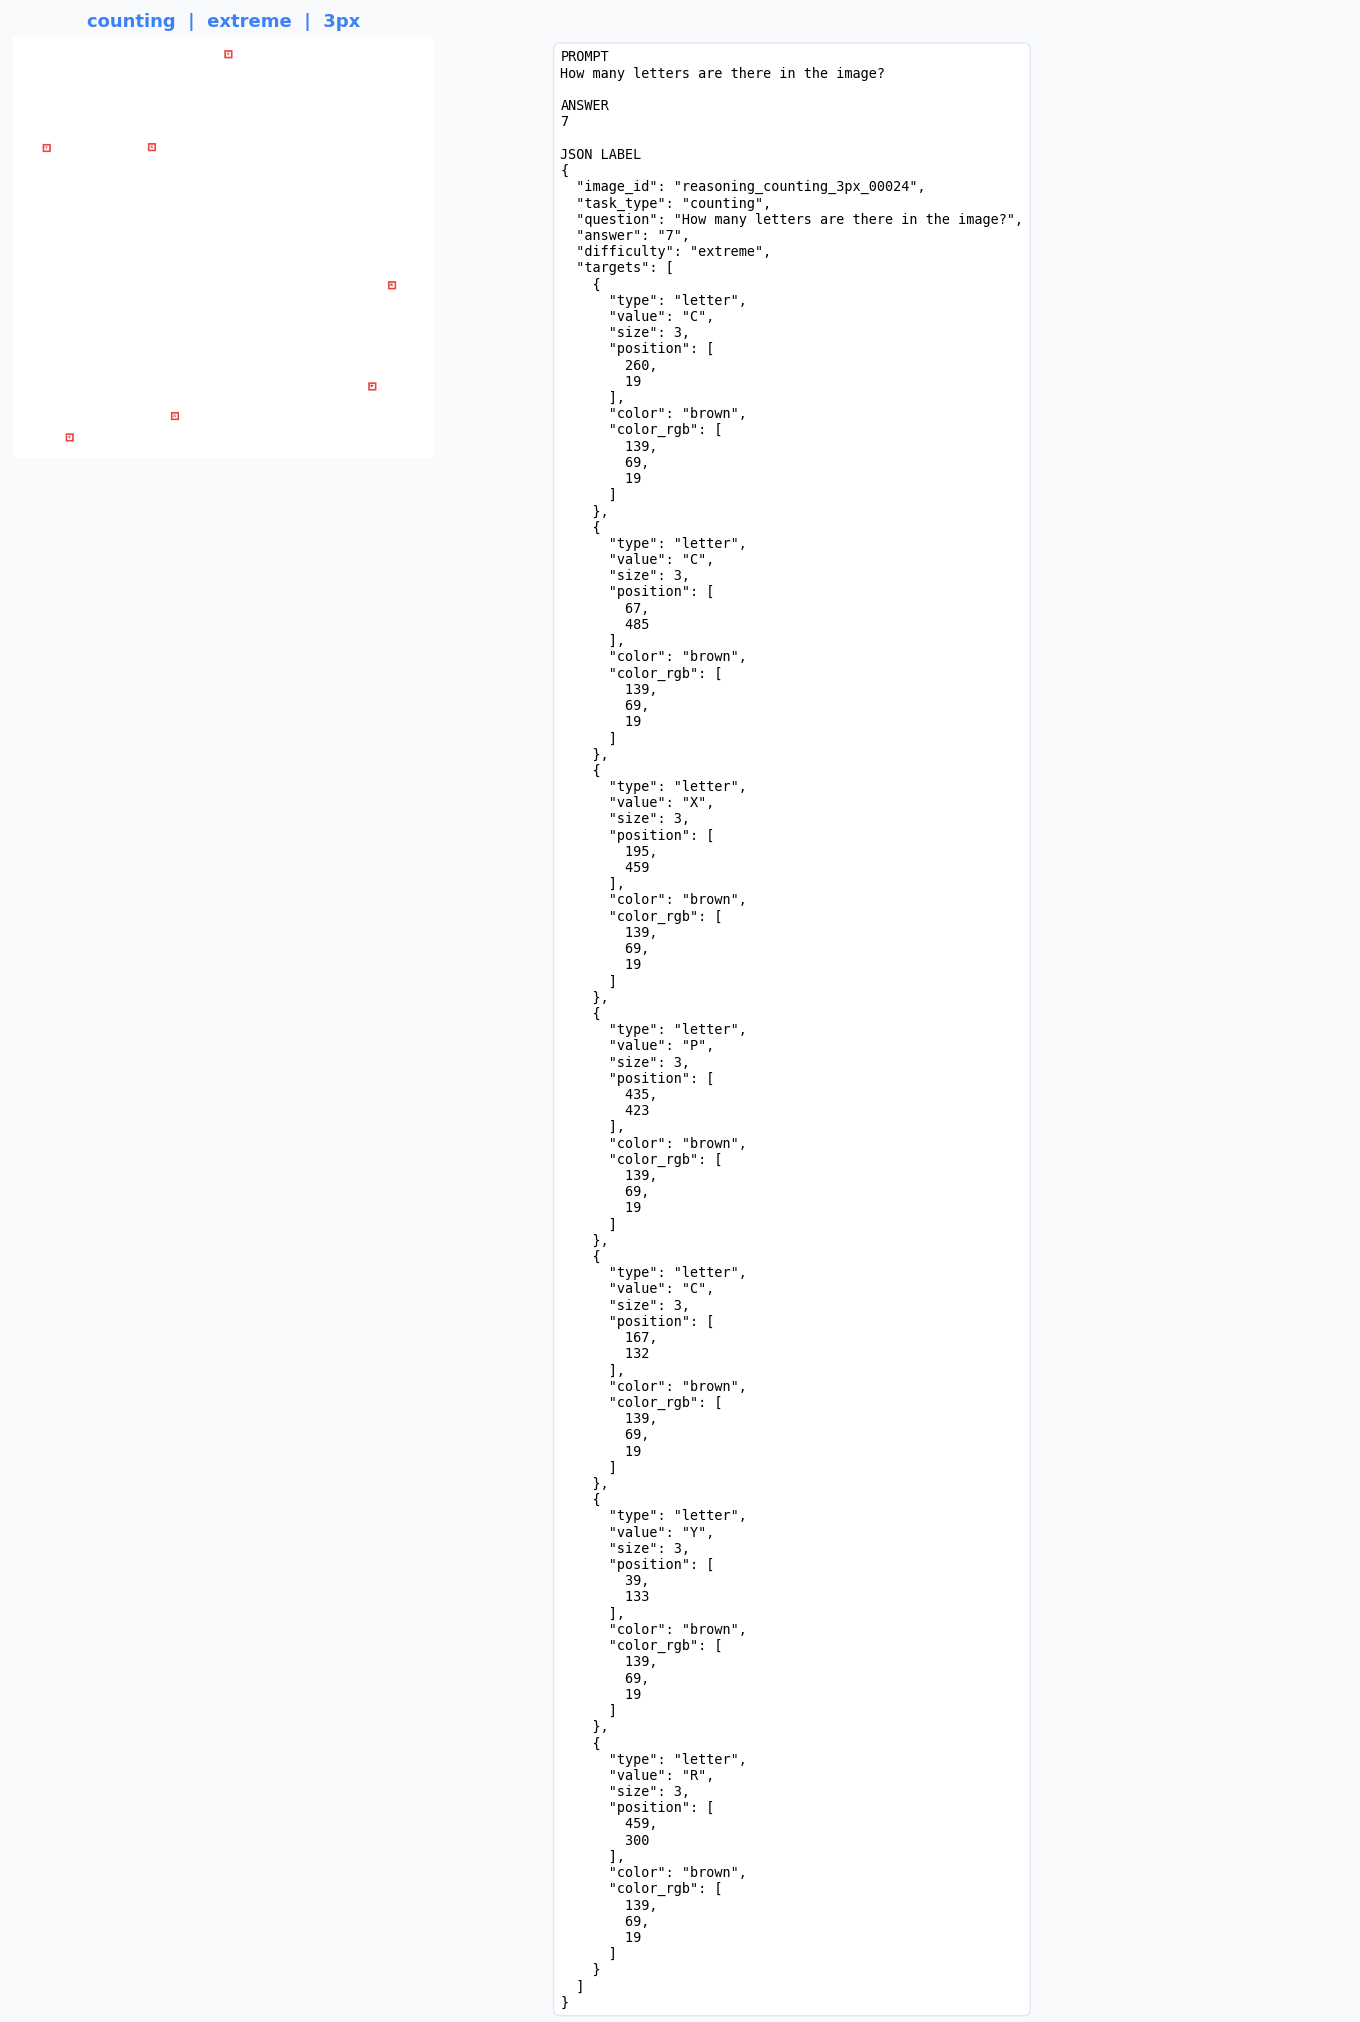

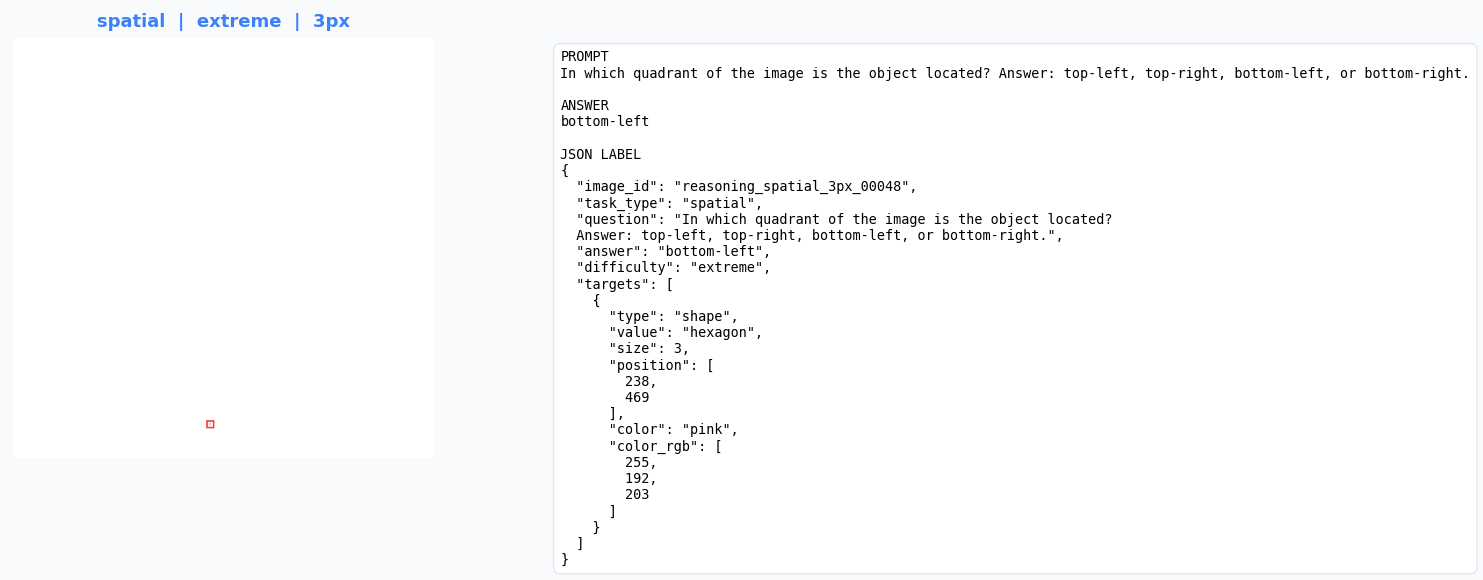

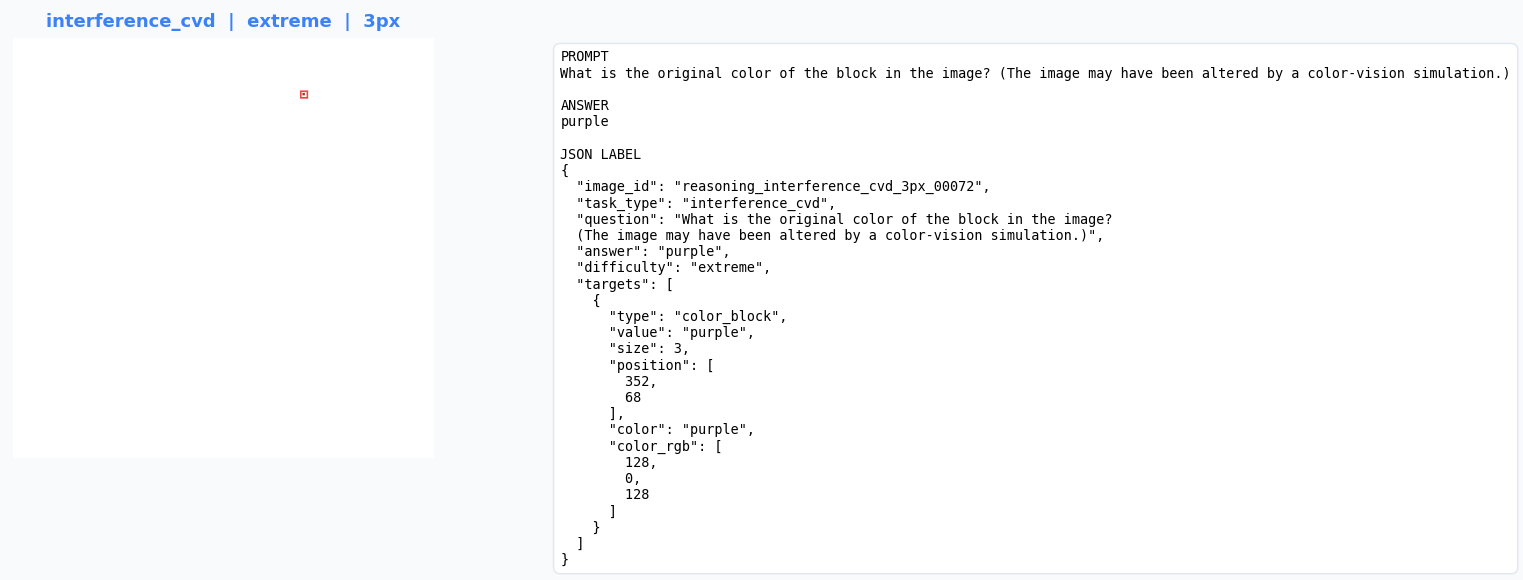

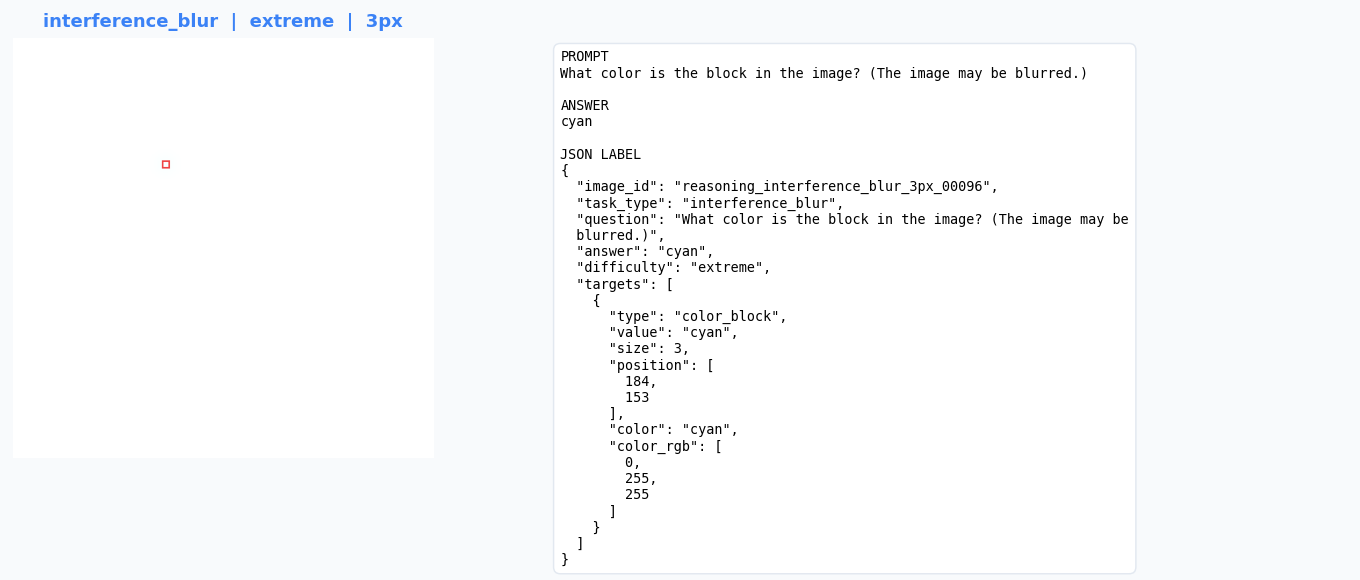

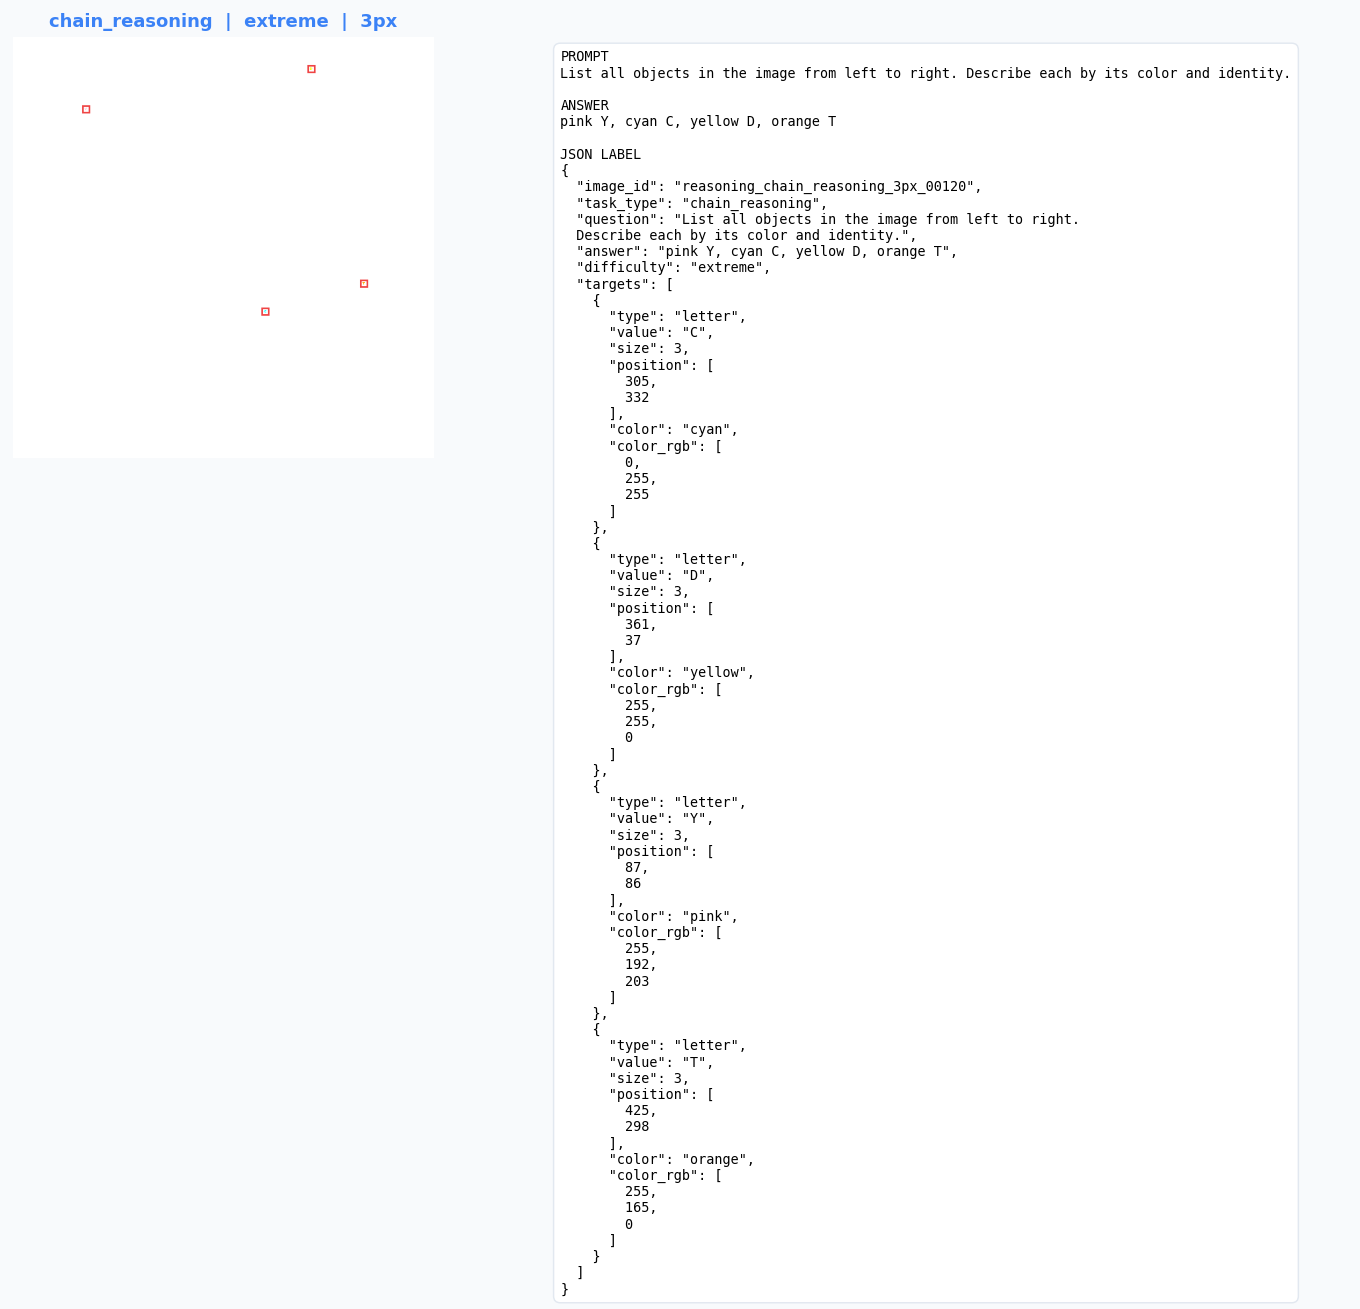

In [6]:
# Show one detailed card per reasoning task type
shown_tasks = set()
for s in r_data["samples"]:
    if s["task_type"] not in shown_tasks:
        shown_tasks.add(s["task_type"])
        show_card(R_DIR, s)

---
## 6. Difficulty Scaling — Same Task across Target Sizes

Visualize how the **same task type** looks at different pixel sizes (3 → 48 px).  
This validates that the difficulty labels (`extreme` → `easy`) are correct.

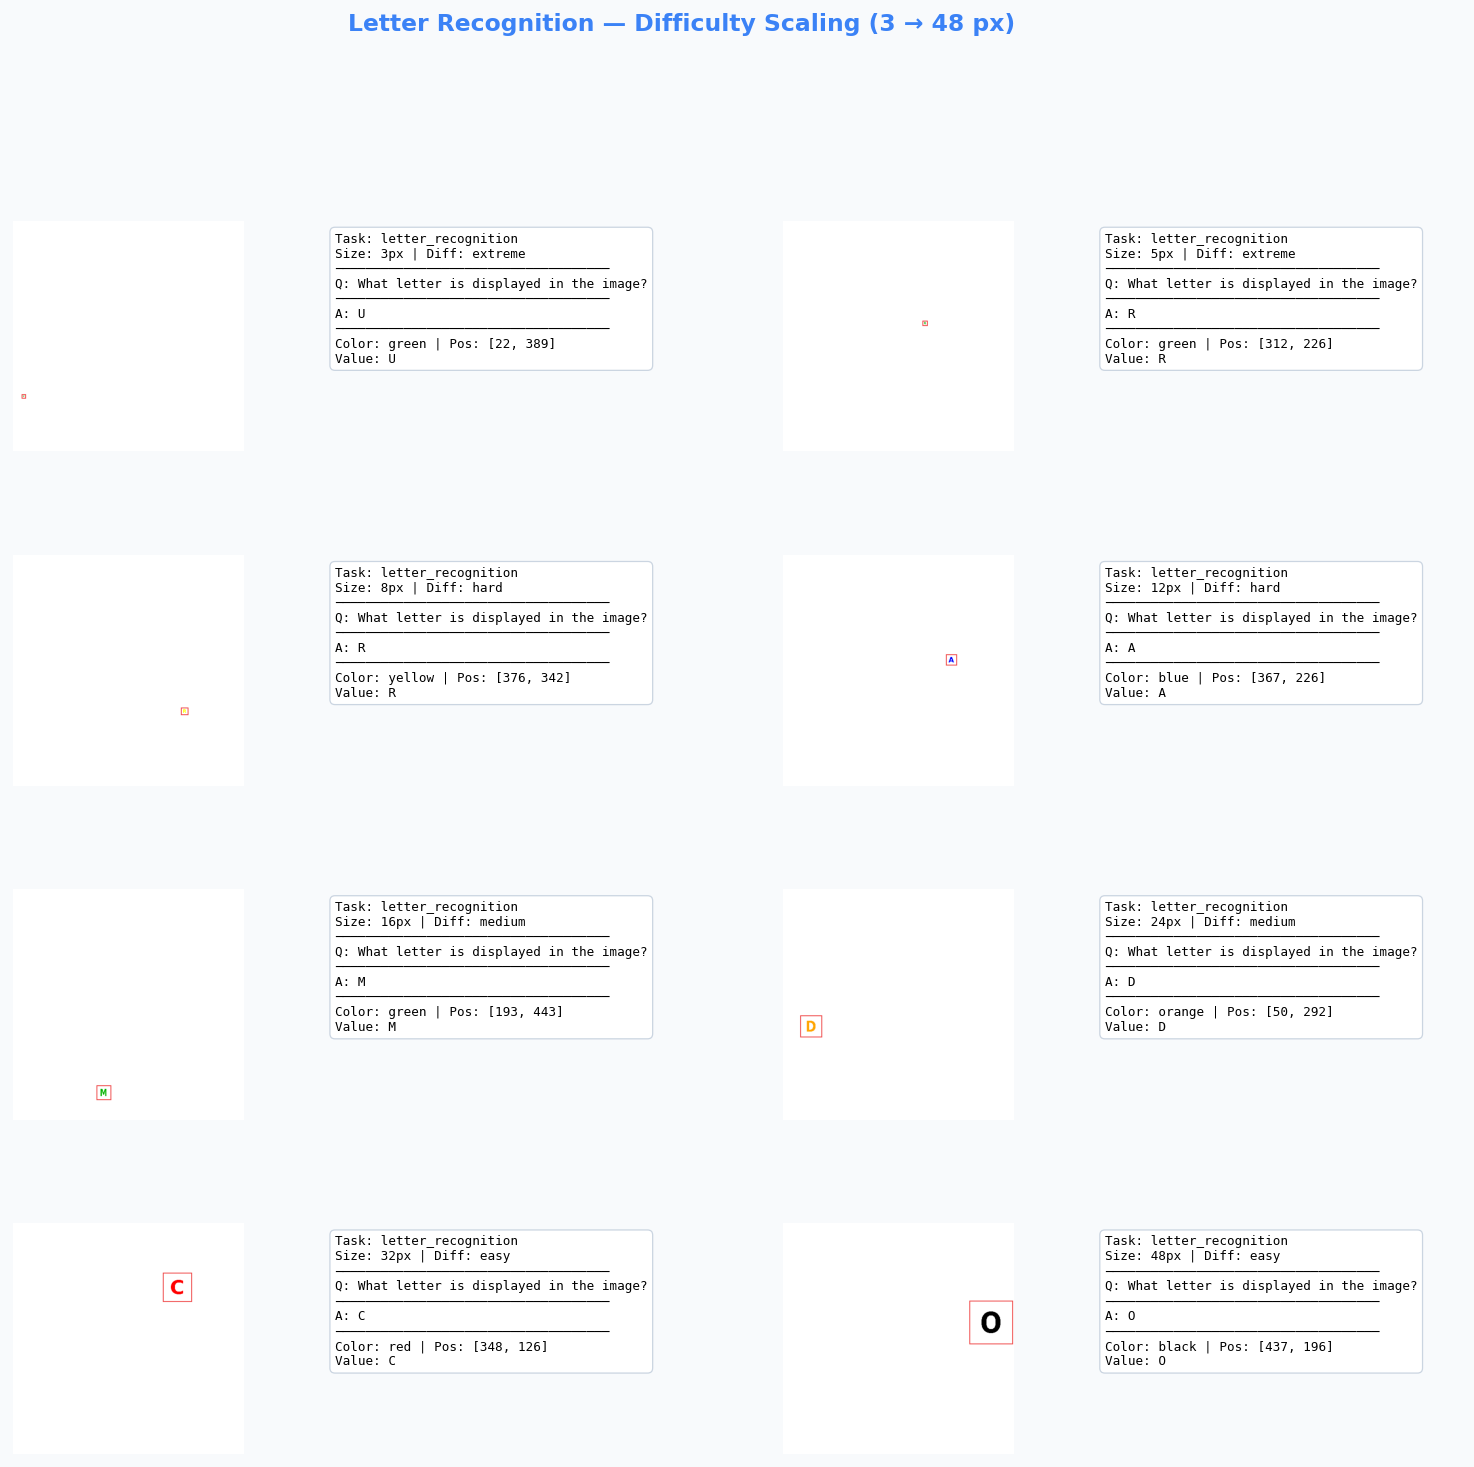

In [7]:
# Pick one sample per size for "letter_recognition" task
letter_samples = [s for s in p_data["samples"] if s["task_type"] == "letter_recognition"]
# Group by target size, take first of each
by_size = {}
for s in letter_samples:
    sz = s["metadata"]["targets"][0]["size"]
    if sz not in by_size:
        by_size[sz] = s
ordered = [by_size[sz] for sz in sorted(by_size)]

show_cards_grid(P_DIR, ordered,
                title="Letter Recognition — Difficulty Scaling (3 → 48 px)",
                cols=2)

---
## 7. Zoomed View — Verifying Small Targets

For extreme/hard samples (≤12 px), crop a 64×64 region around the target and enlarge it to verify the object is rendered correctly.

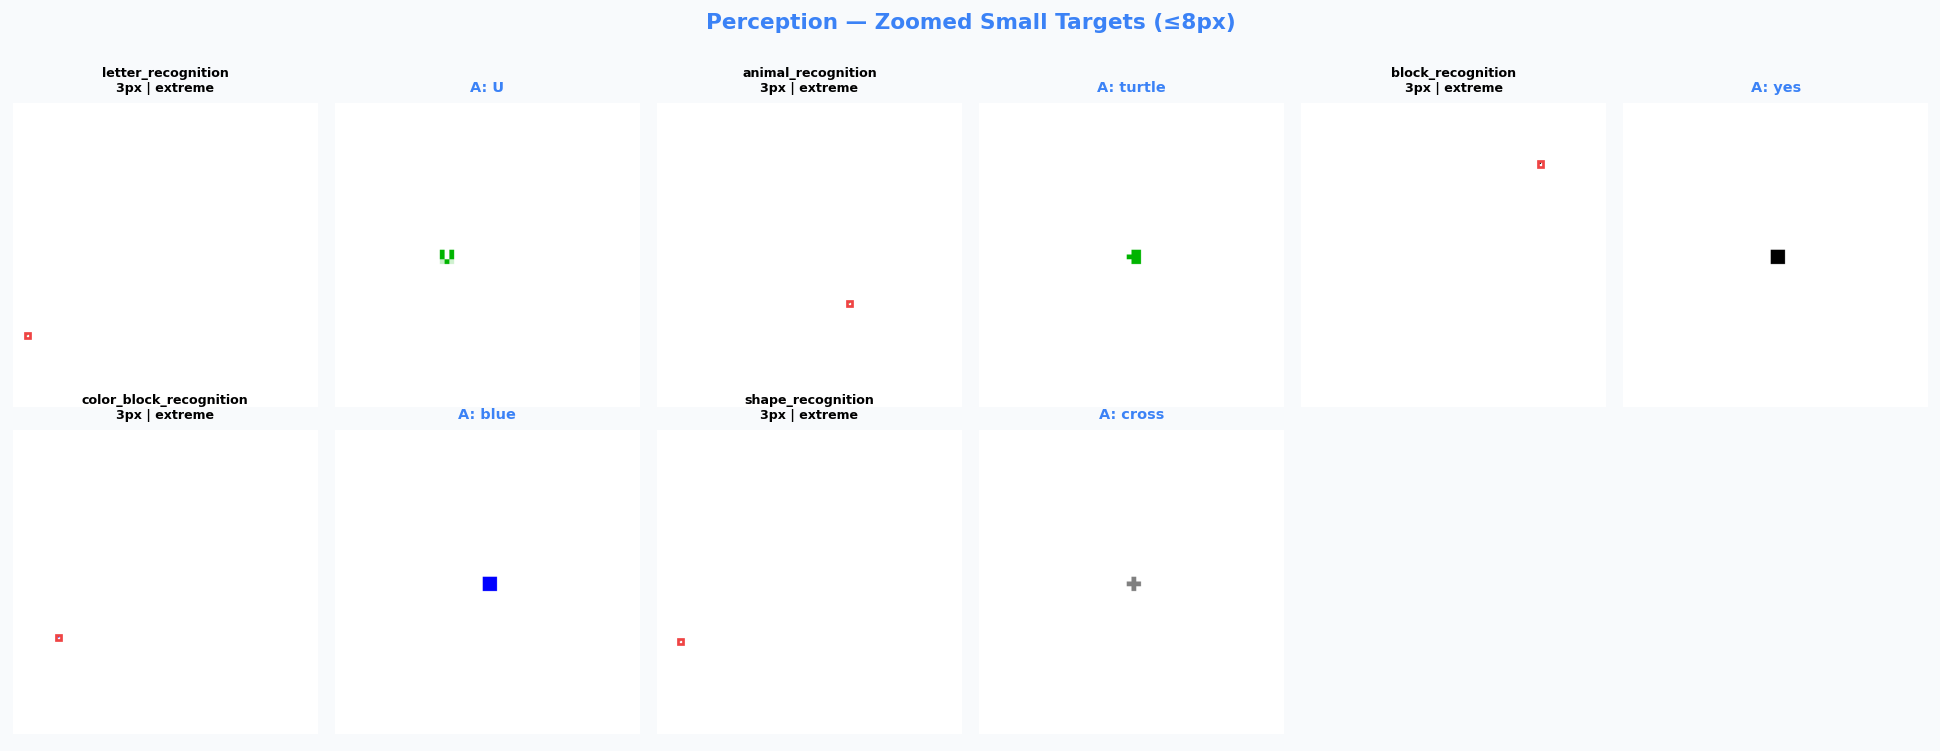

In [8]:
# Zoomed view for small-target samples
def show_zoomed(data_dir, samples, title="", crop_size=64, display_size=192, cols=4):
    n = len(samples)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 5, rows * 2.8), facecolor=BG)
    if rows == 1:
        axes = axes.reshape(1, -1)
    for idx, s in enumerate(samples):
        r, c = divmod(idx, cols)
        # Full image with box
        ax_full = axes[r, c * 2]
        img = Image.open(Path(data_dir) / s["image_path"])
        t = s["metadata"]["targets"][0]
        x, y, sz = t["position"][0], t["position"][1], t["size"]
        ax_full.imshow(img)
        pad = max(3, sz // 2)
        rect = mpatches.Rectangle((x - pad, y - pad), sz + 2 * pad, sz + 2 * pad,
                                   linewidth=1.5, edgecolor=WARN, facecolor="none")
        ax_full.add_patch(rect)
        ax_full.set_title(f"{s['task_type']}\n{sz}px | {s['difficulty']}", fontsize=7)
        ax_full.axis("off")

        # Zoomed crop
        ax_zoom = axes[r, c * 2 + 1]
        half = crop_size // 2
        cx, cy = x + sz // 2, y + sz // 2
        left = max(0, cx - half)
        top = max(0, cy - half)
        crop = img.crop((left, top, left + crop_size, top + crop_size))
        crop = crop.resize((display_size, display_size), Image.NEAREST)
        ax_zoom.imshow(crop)
        ax_zoom.set_title(f"A: {s['answer']}", fontsize=8, color=ACCENT)
        ax_zoom.axis("off")

    # Hide unused axes
    for idx in range(n, rows * cols):
        r, c = divmod(idx, cols)
        axes[r, c * 2].axis("off")
        axes[r, c * 2 + 1].axis("off")

    if title:
        fig.suptitle(title, fontsize=12, fontweight="bold", color=ACCENT, y=1.02)
    plt.tight_layout()
    plt.show()

# Gather one small-target sample per perception task
small_p = []
seen = set()
for s in p_data["samples"]:
    key = s["task_type"]
    if key not in seen and s["metadata"]["targets"][0]["size"] <= 8:
        seen.add(key)
        small_p.append(s)

show_zoomed(P_DIR, small_p, title="Perception — Zoomed Small Targets (≤8px)", cols=3)

---
## 8. Dataset Integrity Checks

Automated validation:
- Every `image_path` exists on disk
- Every sample has non-empty `question` and `answer`
- Difficulty labels are consistent with target size
- Target positions are within canvas bounds

In [10]:
DIFFICULTY_MAP = {
    "extreme": lambda sz: sz <= 5,
    "hard":    lambda sz: 5 < sz <= 12,
    "medium":  lambda sz: 12 < sz <= 24,
    "easy":    lambda sz: sz > 24,
}

def validate_dataset(name, data_dir, data):
    errors = []
    samples = data["samples"]
    for s in samples:
        img_path = Path(data_dir) / s["image_path"]
        if not img_path.exists():
            errors.append(f"[{s['image_id']}] Missing image: {img_path}")
        if not s.get("question"):
            errors.append(f"[{s['image_id']}] Empty question")
        if not s.get("answer"):
            errors.append(f"[{s['image_id']}] Empty answer")
        for t in s["metadata"]["targets"]:
            sz = t["size"]
            diff = s["difficulty"]
            if diff in DIFFICULTY_MAP and not DIFFICULTY_MAP[diff](sz):
                errors.append(f"[{s['image_id']}] Difficulty '{diff}' vs size {sz}px")
            cs = s["metadata"]["canvas_size"]
            cw = cs[0] if isinstance(cs, list) else cs
            ch = cs[1] if isinstance(cs, list) else cs
            x, y = t["position"]
            if not (0 <= x < cw and 0 <= y < ch):
                errors.append(f"[{s['image_id']}] Target out of bounds: ({x},{y})")
    n = len(samples)
    if errors:
        print(f"✗ {name}: {len(errors)} error(s) in {n} samples")
        for e in errors[:10]:
            print(f"  {e}")
    else:
        print(f"✓ {name}: All {n} samples passed integrity checks")
    return errors

p_err = validate_dataset("Perception", P_DIR, p_data)
r_err = validate_dataset("Reasoning",  R_DIR, r_data)

✓ Perception: All 120 samples passed integrity checks
✗ Reasoning: 11 error(s) in 144 samples
  [reasoning_comparison_5px_00003] Difficulty 'extreme' vs size 10px
  [reasoning_comparison_8px_00006] Difficulty 'hard' vs size 16px
  [reasoning_comparison_8px_00008] Difficulty 'hard' vs size 4px
  [reasoning_comparison_16px_00012] Difficulty 'medium' vs size 32px
  [reasoning_comparison_16px_00013] Difficulty 'medium' vs size 8px
  [reasoning_comparison_16px_00014] Difficulty 'medium' vs size 32px
  [reasoning_comparison_24px_00016] Difficulty 'medium' vs size 40px
  [reasoning_comparison_24px_00017] Difficulty 'medium' vs size 40px
  [reasoning_comparison_32px_00018] Difficulty 'easy' vs size 19px
  [reasoning_comparison_32px_00020] Difficulty 'easy' vs size 16px


In [11]:
# Note: "comparison" tasks intentionally have TWO targets of DIFFERENT sizes
# (one smaller, one larger). The difficulty is based on the primary target size,
# so the secondary target may not match the difficulty label — this is expected.
comparison_errs = [e for e in r_err if "comparison" in e]
other_errs = [e for e in r_err if "comparison" not in e]
print(f"Comparison task size-mismatch (expected by design): {len(comparison_errs)}")
print(f"Other errors: {len(other_errs)}")
if other_errs:
    for e in other_errs:
        print(f"  {e}")
else:
    print("✓ No unexpected errors")

Comparison task size-mismatch (expected by design): 11
Other errors: 0
✓ No unexpected errors


---
## 9. Dataset Statistics Summary

Distribution of samples across task types, difficulties, and target sizes.

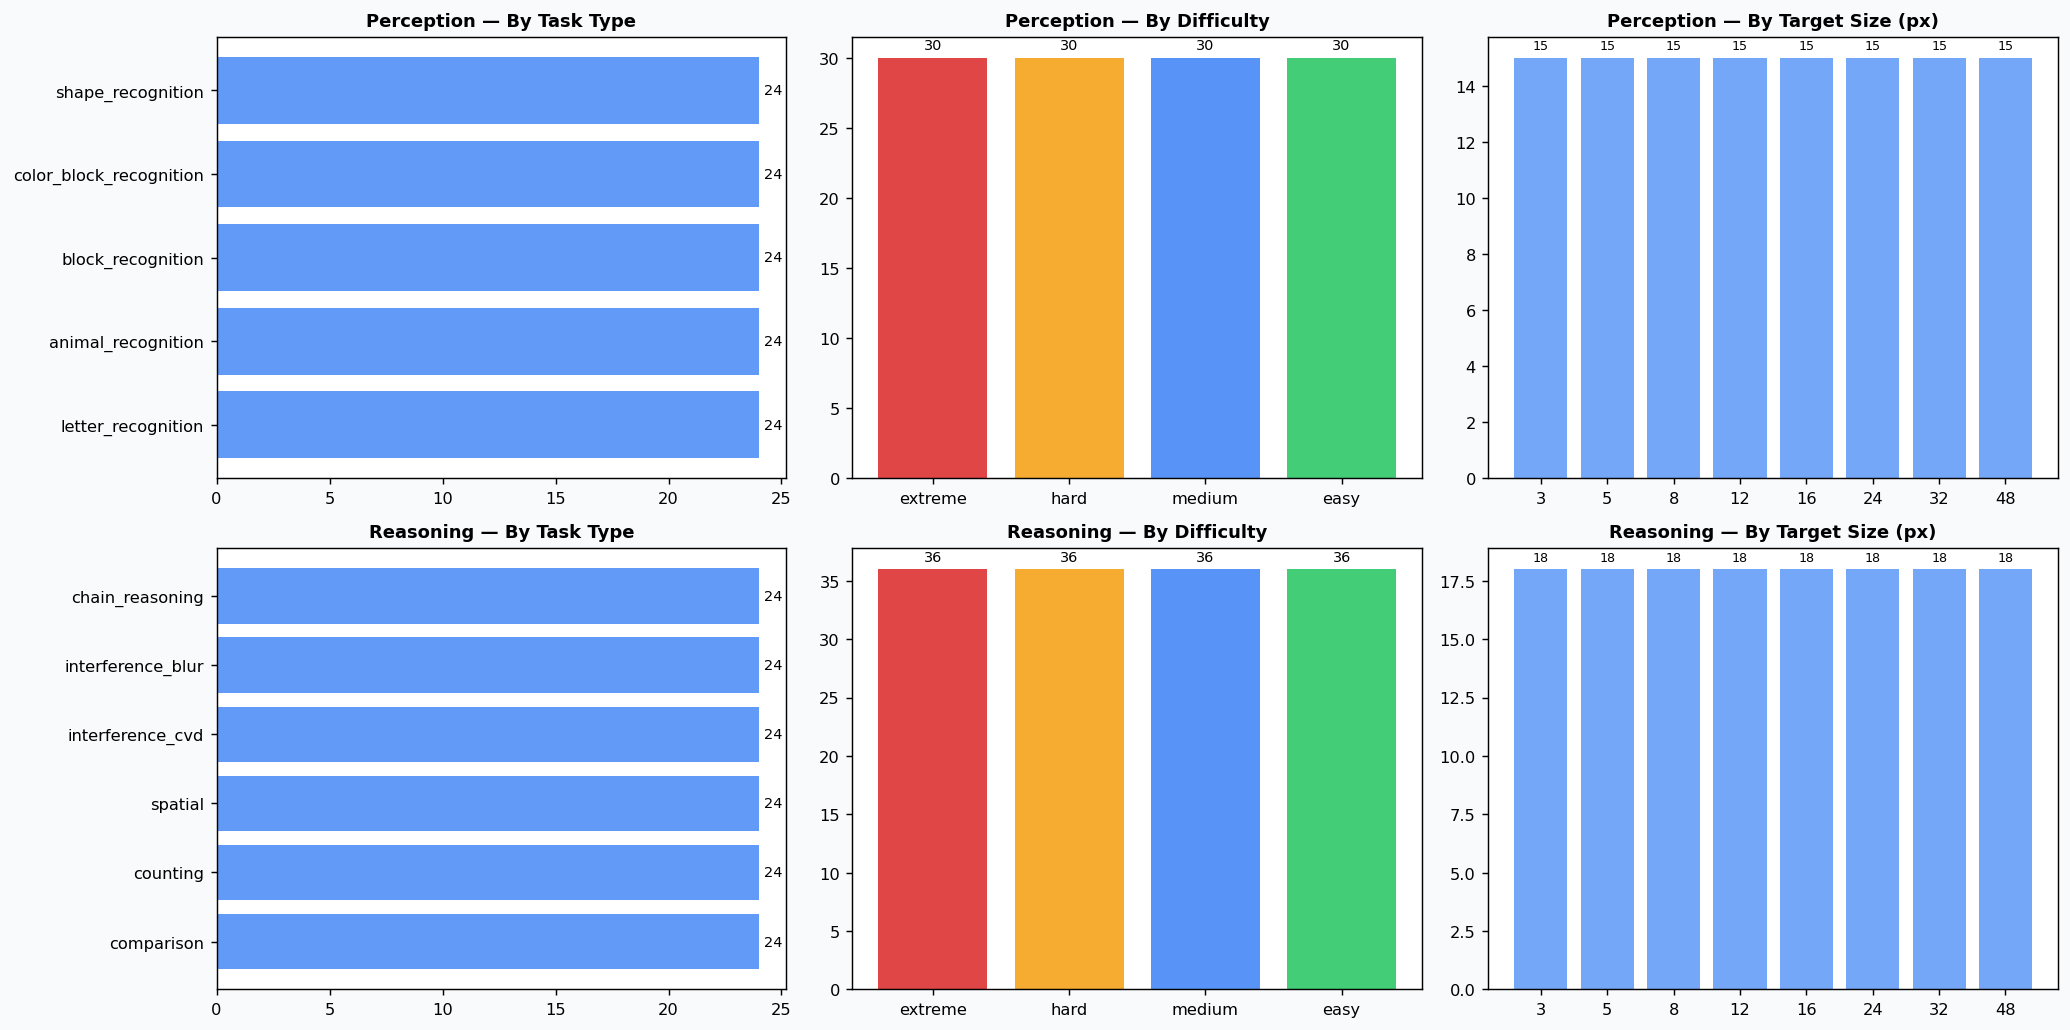


Total samples: 264  (Perception: 120, Reasoning: 144)


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), facecolor=BG)

for row, (name, data) in enumerate([("Perception", p_data), ("Reasoning", r_data)]):
    samples = data["samples"]

    # By task type
    task_counts = Counter(s["task_type"] for s in samples)
    ax = axes[row, 0]
    bars = ax.barh(list(task_counts.keys()), list(task_counts.values()), color=ACCENT, alpha=0.8)
    ax.set_title(f"{name} — By Task Type")
    ax.bar_label(bars, padding=3, fontsize=8)

    # By difficulty
    diff_order = ["extreme", "hard", "medium", "easy"]
    diff_counts = Counter(s["difficulty"] for s in samples)
    diff_colors = ["#dc2626", "#f59e0b", "#3b82f6", "#22c55e"]
    ax = axes[row, 1]
    vals = [diff_counts.get(d, 0) for d in diff_order]
    bars = ax.bar(diff_order, vals, color=diff_colors, alpha=0.85)
    ax.set_title(f"{name} — By Difficulty")
    ax.bar_label(bars, padding=3, fontsize=8)

    # By target size
    size_counts = Counter(s["metadata"]["targets"][0]["size"] for s in samples)
    sizes_sorted = sorted(size_counts.keys())
    ax = axes[row, 2]
    bars = ax.bar([str(s) for s in sizes_sorted],
                  [size_counts[s] for s in sizes_sorted],
                  color=ACCENT, alpha=0.7)
    ax.set_title(f"{name} — By Target Size (px)")
    ax.bar_label(bars, padding=3, fontsize=7)

plt.tight_layout()
plt.show()

total = p_data["dataset_info"]["num_samples"] + r_data["dataset_info"]["num_samples"]
print(f"\nTotal samples: {total}  "
      f"(Perception: {p_data['dataset_info']['num_samples']}, "
      f"Reasoning: {r_data['dataset_info']['num_samples']})")